# IMU 滤波与作图（重构版）

这一版把 notebook 拆成：
1. **配置区**：只改参数（采样率、文件路径、各类滤波器参数）
2. **数据读取**：统一输出 `df_raw`（后续所有处理都从 raw 开始）
3. **处理流水线**：用不同滤波器/方法生成不同 `df_xxx`，不再反复覆盖 `df_proc`
4. **作图**：用统一绘图函数减少重复；重力部分只画 **AccX**


✅ 配置完成
文件: accelero and gyro data.txt
fs: 50.0 Hz
数据长度: 6248
总时长(s): 124.94
alpha = 0.9509769232943149


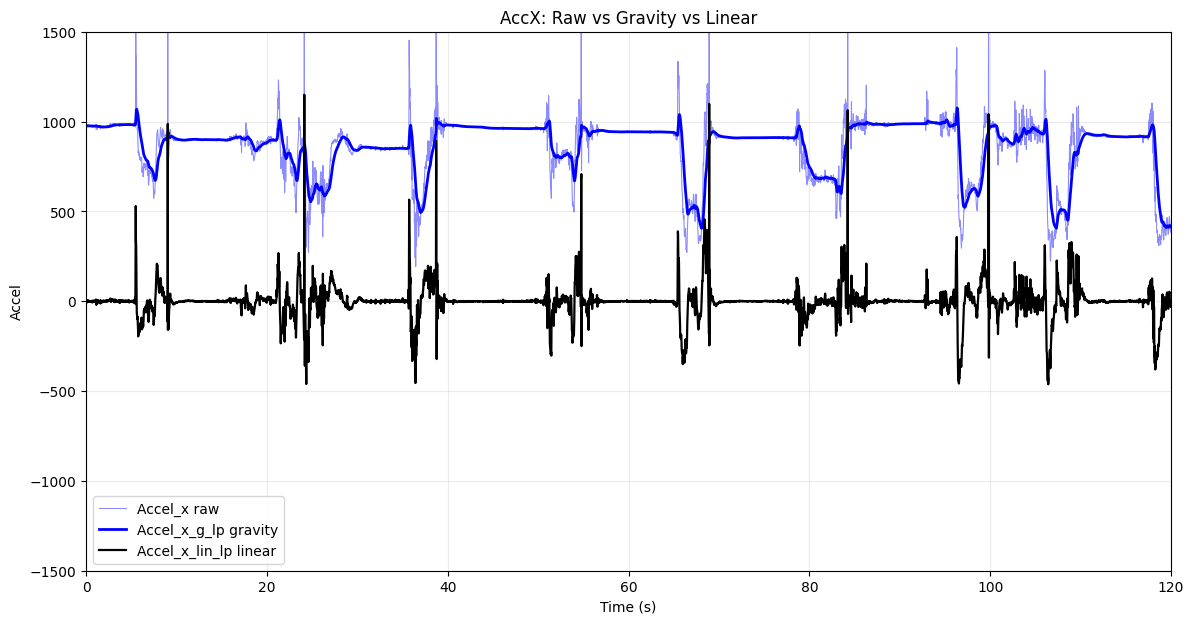

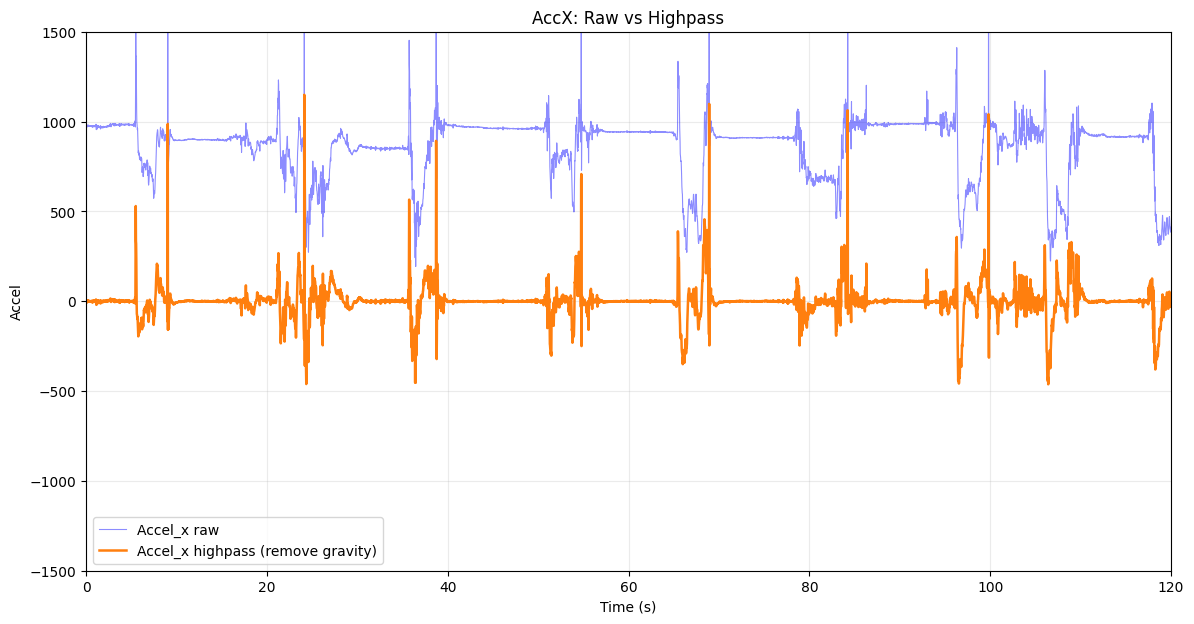

IIR alpha = 0.9509769232943149


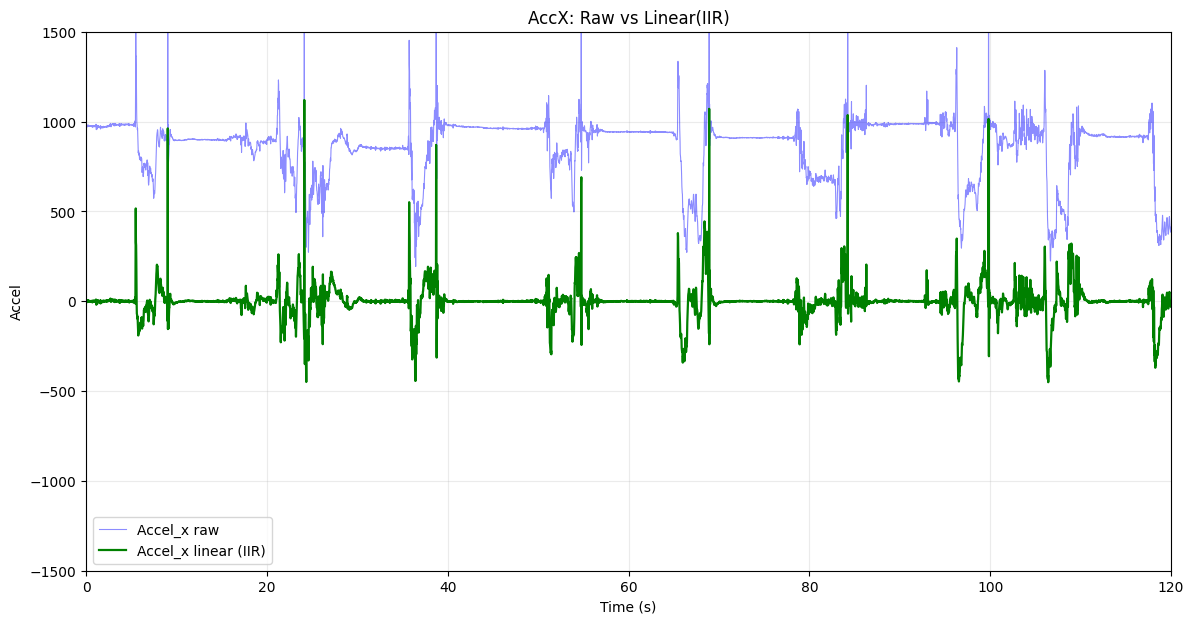

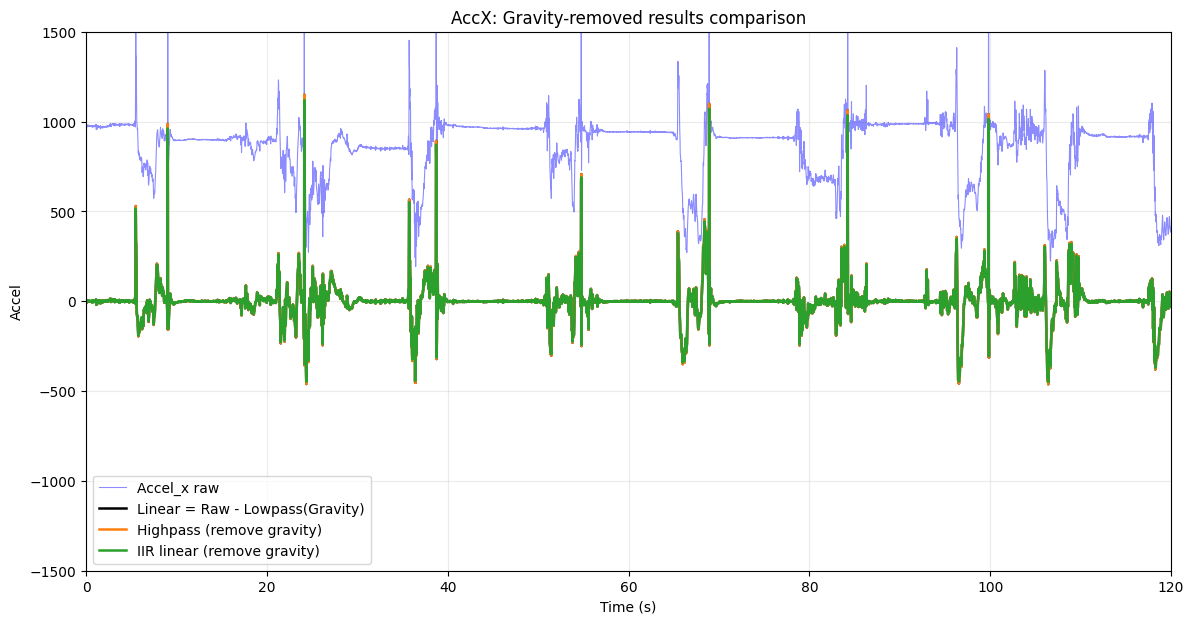

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from imu_processing import (
    load_raw_imu_txt,
    design_sos,
    apply_causal_sos_filter,
    apply_zero_phase_filter,
    gravity_lowpass_subtract,
    gravity_remove_iir_first_order,
    plot_triplet_raw_vs_processed,
    plot_accx_gravity_only,
    
)

# =========================
# 0) 参数集中区（你只改这里）
# =========================
CONFIG = {
    # 数据
    "raw_file_path": "accelero and gyro data.txt",
    "fs": 50.0,  # 采样率 Hz

    # —— 统一定义：不同目的的滤波器（只改参数即可复用）——
    # 备注：bandpass/bandstop 用 lowcut_hz/highcut_hz；low/high pass 用 cutoff_hz
    "filters": {

        # 示例：低通提取重力（Acc 低频）
        "gravity_lowpass": {
            "design": "butter",
            "filter_type": "lowpass",
            "order":1,
            "cutoff_hz": 0.4,
        },


#cutoff 0.4Hz 是个经验值，适合大多数日常活动的重力提取。你可以根据实际情况调整这个值：



        # 示例：直接高通去重力（与 lowpass-subtract 是两条不同 pipeline）
        "remove_gravity_highpass": {
            "design": "butter",
            "filter_type": "highpass",
            "order": 1,
            "cutoff_hz": 0.4,
        },
    },

    # 复现 C++ 的稳态初始化（对因果 IIR 起始瞬态很关键）
    "steady_init_iter": 5000,

    # 绘图参数
    "plot": {
        "alpha_raw": 0.45,
        "lw_proc": 1.8,
        "xlim": (0, 120),
        "acc_ylim": (-1500, 1500),
        "gyro_ylim": (-250, 250),
    },
}

# =========================
# 1) 列定义 & 颜色（统一）
# =========================
RAW_IMU_COLS = ["Accel_x", "Accel_y", "Accel_z", "gyro_x", "gyro_y", "gyro_z"]
ACC_COLS = ["Accel_x", "Accel_y", "Accel_z"]
GYRO_COLS = ["gyro_x", "gyro_y", "gyro_z"]

AXIS_COLORS = {"x": "blue", "y": "green", "z": "red"}

print("✅ 配置完成")
print("文件:", CONFIG["raw_file_path"])
print("fs:", CONFIG["fs"], "Hz")

# =========================
# 2) 读取 raw data（后续所有处理都从 df_raw 开始）
# =========================
fs = float(CONFIG["fs"])
df_raw = load_raw_imu_txt(CONFIG["raw_file_path"], fs=fs, imu_cols=RAW_IMU_COLS)

print("数据长度:", len(df_raw))
print("总时长(s):", df_raw["time_sec"].iloc[-1] if len(df_raw) else None)
df_raw.head()


# 3B) 重力（lowpass 提取）+ 去重力（raw - gravity）：raw -> df_grav_lp
df_grav_lp = gravity_lowpass_subtract(
    df_raw,
    acc_cols=ACC_COLS,
    fs=fs,
    fc=float(CONFIG["filters"]["gravity_lowpass"]["cutoff_hz"]),
    order=int(CONFIG["filters"]["gravity_lowpass"]["order"]),
    steady_init_iter=int(CONFIG["steady_init_iter"]),
    causal_suffix="_g",
    linear_suffix="_lin",
)



# 3C) 公式法 1阶 IIR 去重力（可选对比）：raw -> df_grav_iir
df_grav_iir, alpha = gravity_remove_iir_first_order(
    df_raw,
    acc_cols=ACC_COLS,
    fs=fs,
    fc=float(CONFIG["filters"]["gravity_lowpass"]["cutoff_hz"]),
    init_mode="mean",
    init_mean_sec=1.0,
    suffix_g="_g",
    suffix_lin="_lin",
)
print("alpha =", alpha)





###作图部分


p = CONFIG["plot"]
xlim = tuple(p["xlim"]) if p.get("xlim") else None


# =========================================================
# 4C) 你要求的“三个滤波器（AccX）”与作图
#   1) 重力滤波器（低频）：raw vs gravity(lowpass)；并用 raw-gravity 得到去重力
#   2) 直接高通：raw vs highpass
#   3) IIR 公式法（源代码法）：raw vs gravity(iir) vs linear(iir)
#   最后：把三种“去重力结果”叠在一张图里
# =========================================================

from imu_processing import plot_accx_methods_comparison

# ---- (1) 低通提取重力 + 相减 ----
df_lp = gravity_lowpass_subtract(
    df_raw,
    acc_cols=ACC_COLS,
    fs=fs,
    fc=float(CONFIG["filters"]["gravity_lowpass"]["cutoff_hz"]),
    order=int(CONFIG["filters"]["gravity_lowpass"]["order"]),
    steady_init_iter=int(CONFIG["steady_init_iter"]),
    causal_suffix="_g_lp",
    linear_suffix="_lin_lp",
)

plot_accx_gravity_only(
    df_raw=df_raw,
    df_with_gravity=df_lp,
    time_col="time_sec",
    accx_col="Accel_x",
    gravity_suffix="_g_lp",
    linear_suffix="_lin_lp",
    xlim=xlim,
    ylim=tuple(p["acc_ylim"]),
    alpha_raw=float(p["alpha_raw"]),
)

# ---- (2) 直接高通去重力 ----
hp_spec = CONFIG["filters"]["remove_gravity_highpass"]
hp_sos = design_sos(fs=fs, filter_spec=hp_spec)
df_hp = apply_causal_sos_filter(
    df_raw,
    cols=["Accel_x"],
    sos=hp_sos,
    steady_init_iter=int(CONFIG["steady_init_iter"]),
    suffix="_hp",
)

plt.figure(figsize=(14, 7))
t = df_raw["time_sec"]
plt.plot(t, df_raw["Accel_x"], alpha=float(p["alpha_raw"]), lw=0.8, label="Accel_x raw", color="blue")
plt.plot(t, df_hp["Accel_x_hp"], lw=1.8, label="Accel_x highpass (remove gravity)", color="tab:orange")
plt.xlabel("Time (s)")
plt.ylabel("Accel")
plt.title("AccX: Raw vs Highpass")
plt.xlim(*xlim)
plt.ylim(*tuple(p["acc_ylim"]))
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

# ---- (3) IIR 公式法去重力（源代码实现） ----
df_iir, alpha = gravity_remove_iir_first_order(
    df_raw,
    acc_cols=ACC_COLS,
    fs=fs,
    fc=float(CONFIG["filters"]["gravity_lowpass"]["cutoff_hz"]),
    init_mode="mean",
    init_mean_sec=1.0,
    suffix_g="_g_iir",
    suffix_lin="_lin_iir",
)
print("IIR alpha =", alpha)

plt.figure(figsize=(14, 7))
plt.plot(t, df_raw["Accel_x"], alpha=float(p["alpha_raw"]), lw=0.8, label="Accel_x raw", color="blue")
#plt.plot(t, df_iir["Accel_x_g_iir"], lw=2.0, label="Accel_x gravity (IIR)", color="blue")
plt.plot(t, df_iir["Accel_x_lin_iir"], lw=1.6, label="Accel_x linear (IIR)", color="green")
plt.xlabel("Time (s)")
plt.ylabel("Accel")
plt.title("AccX: Raw vs Linear(IIR)")
plt.xlim(*xlim)
plt.ylim(*tuple(p["acc_ylim"]))
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

# ---- 最终：三种“去重力结果”叠在一张图里 ----
plot_accx_methods_comparison(
    df_raw=df_raw,
    time_col="time_sec",
    accx_col="Accel_x",
    series=[
        ("Linear = Raw - Lowpass(Gravity)", df_lp["Accel_x_lin_lp"]),
        ("Highpass (remove gravity)", df_hp["Accel_x_hp"]),
        ("IIR linear (remove gravity)", df_iir["Accel_x_lin_iir"]),
    ],
    title="AccX: Gravity-removed results comparison",
    xlim=xlim,
    ylim=tuple(p["acc_ylim"]),
    alpha_raw=float(p["alpha_raw"]),
)



## 5) 如何新增/切换滤波器（只改参数）

1. 在 `CONFIG['filters']` 里新增一个 spec（例如 highpass、bandstop）。
2. `sos = design_sos(fs=fs, filter_spec=spec)`
3. `df_xxx = apply_causal_sos_filter(df_raw, cols=..., sos=sos, suffix='...')`

这样你永远保持：`df_raw` 是 raw；`df_xxx` 是某个明确处理结果。


✅ raw loaded: 6248 samples, duration(s)= 124.94

=== Bandpass filter spec ===

=== Bandpass SOS coefficients (each row = [b0 b1 b2 a0 a1 a2]) ===
[[ 0.02452161  0.         -0.02452161  1.         -1.9460285   0.95095678]]
design: butter
filter_type: bandpass
order: 1
lowcut_hz: 0.4
highcut_hz: 0.8
sos shape: (1, 6)

=== Gravity remove (IIR) ===
fc: 0.1 Hz
alpha: 0.987512256523656


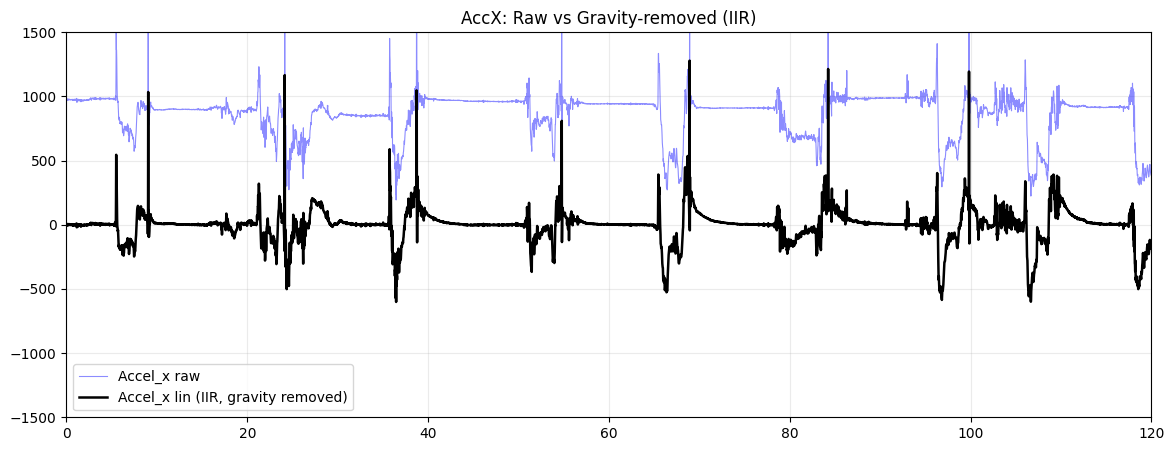

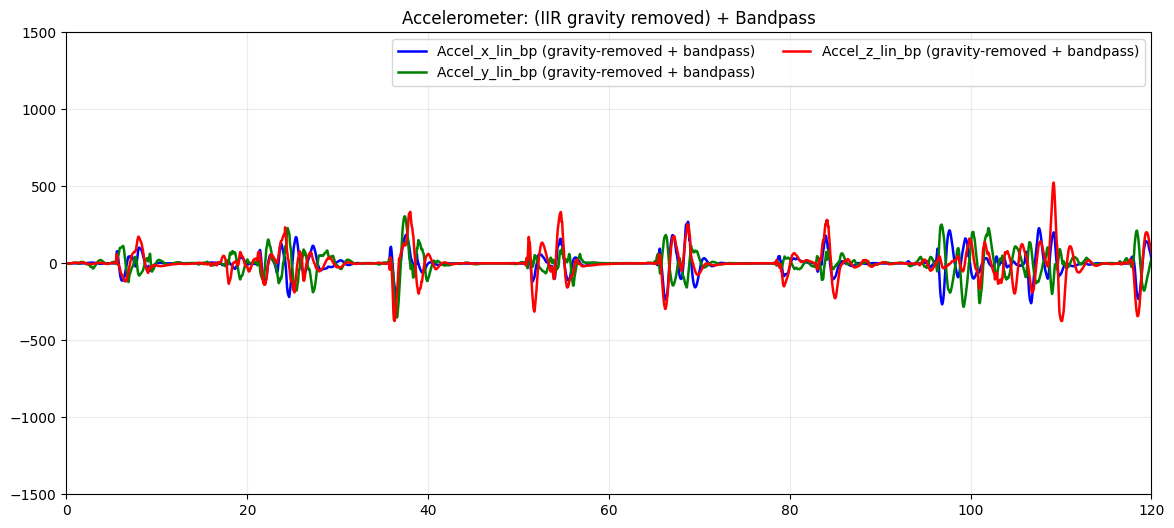

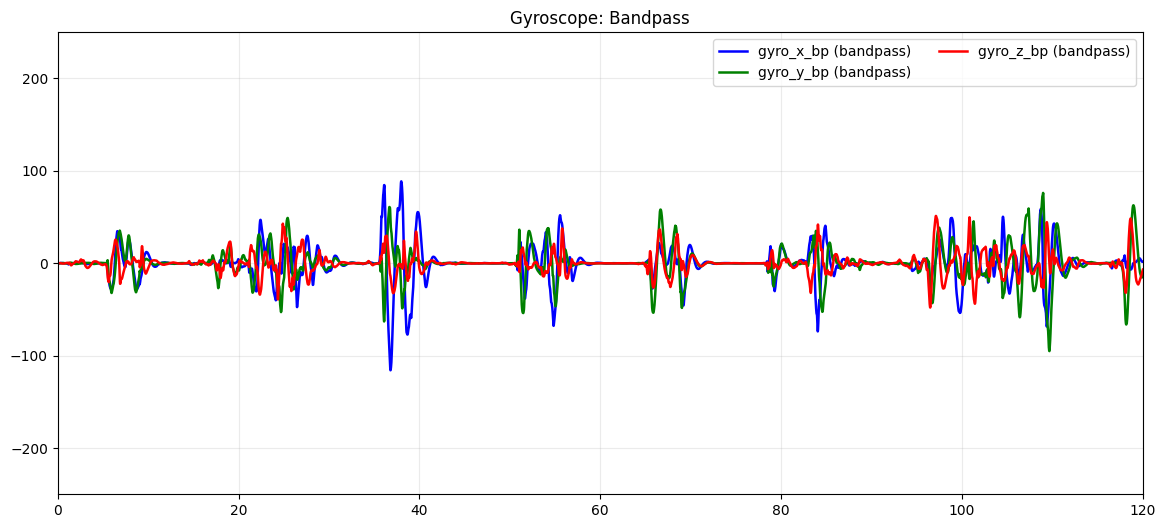

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from imu_processing import (
    load_raw_imu_txt,
    design_sos,
    apply_causal_sos_filter,
    gravity_remove_iir_first_order,
)

# =========================
# 0) 配置（你只改这里）
# =========================
CONFIG = {
    "raw_file_path": "accelero and gyro data.txt",  # <- 改成你的文件名
    "fs": 50.0,

    # 带通滤波器：0.4 ~ 1 Hz
    "bandpass": {
        "design": "butter",
        "filter_type": "bandpass",   # <- 需要的话你可以改成 lowpass/highpass/bandstop
        "order": 1,
        "lowcut_hz": 0.4,            # <- 改这里
        "highcut_hz": 0.8,           # <- 改这里
    },

    # IIR 去重力（公式法）
    "gravity_iir": {
        "fc": 0.1,                   # 重力估计低通截止（常用 0.2~0.8）
        "init_mode": "mean",
        "init_mean_sec": 1.0,
    },

    "plot": {
        "xlim": (0,120),
        "acc_ylim": (-1500, 1500),
        "gyro_ylim": (-250, 250),
        "alpha_raw": 0.45,
    }
}

RAW_IMU_COLS = ["Accel_x","Accel_y","Accel_z","gyro_x","gyro_y","gyro_z"]
ACC_COLS = ["Accel_x","Accel_y","Accel_z"]
GYRO_COLS = ["gyro_x","gyro_y","gyro_z"]
AXIS_COLORS = {"x": "blue", "y": "green", "z": "red"}

# =========================
# 1) 读取 raw data
# =========================
fs = float(CONFIG["fs"])
df_raw = load_raw_imu_txt(CONFIG["raw_file_path"], fs=fs, imu_cols=RAW_IMU_COLS)
print("✅ raw loaded:", len(df_raw), "samples,", "duration(s)=", df_raw["time_sec"].iloc[-1])

# =========================
# 2) 设计带通滤波器 + 打印参数
# =========================
bp_spec = CONFIG["bandpass"]
bp_sos = design_sos(fs=fs, filter_spec=bp_spec)

print("\n=== Bandpass filter spec ===")
print("\n=== Bandpass SOS coefficients (each row = [b0 b1 b2 a0 a1 a2]) ===")
print(bp_sos)

for k, v in bp_spec.items():
    print(f"{k}: {v}")
print("sos shape:", bp_sos.shape)  # (n_sections, 6)

# =========================
# 3) IIR 方法去重力（对 Acc 三轴）
#    输出：Accel_x_g / Accel_x_lin 等
# =========================
df_iir, alpha = gravity_remove_iir_first_order(
    df_raw,
    acc_cols=ACC_COLS,
    fs=fs,
    fc=float(CONFIG["gravity_iir"]["fc"]),
    init_mode=str(CONFIG["gravity_iir"]["init_mode"]),
    init_mean_sec=float(CONFIG["gravity_iir"]["init_mean_sec"]),
    suffix_g="_g",
    suffix_lin="_lin",
)


print("\n=== Gravity remove (IIR) ===")
print("fc:", CONFIG["gravity_iir"]["fc"], "Hz")
print("alpha:", alpha)

# 简单画一下 AccX：raw vs linear(iir)
t = df_raw["time_sec"].to_numpy()
plt.figure(figsize=(14, 5))
plt.plot(t, df_raw["Accel_x"], alpha=CONFIG["plot"]["alpha_raw"], lw=0.8, label="Accel_x raw", color="blue")
plt.plot(t, df_iir["Accel_x_lin"], lw=1.8, label="Accel_x lin (IIR, gravity removed)", color="black")
plt.title("AccX: Raw vs Gravity-removed (IIR)")
plt.xlim(*CONFIG["plot"]["xlim"])
plt.ylim(*CONFIG["plot"]["acc_ylim"])
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

# =========================
# 4) 对“去重力后的加速度”做带通
#    目标：Accel_*_lin -> Accel_*_lin_bp
# =========================
df_acc_lin = df_iir[["time_sec", "Accel_x_lin", "Accel_y_lin", "Accel_z_lin"]].copy()

df_acc_lin_bp = apply_causal_sos_filter(
    df_acc_lin,
    cols=["Accel_x_lin", "Accel_y_lin", "Accel_z_lin"],
    sos=bp_sos,
    steady_init_iter=0,     # 这里先不用稳态初始化；需要的话可改成 5000
    suffix="_bp",
)

# =========================
# 5) 陀螺仪（raw）直接带通
#    目标：gyro_* -> gyro_*_bp
# =========================
df_gyro_bp = apply_causal_sos_filter(
    df_raw[["time_sec"] + GYRO_COLS].copy(),
    cols=GYRO_COLS,
    sos=bp_sos,
    steady_init_iter=5000,
    suffix="_bp",
)

# =========================
# 6) 展示最终三轴结果
#    - 加速度：去重力(IIR) + 带通
#    - 陀螺仪：带通
# =========================
plt.figure(figsize=(14, 6))
for col in ["Accel_x_lin", "Accel_y_lin", "Accel_z_lin"]:
    axis_key = col.split("_")[1].lower()  # x/y/z（Accel_x_lin -> x）
    plt.plot(
        t,
        df_acc_lin_bp[col + "_bp"],
        lw=1.8,
        color=AXIS_COLORS.get(axis_key, "blue"),
        label=f"{col}_bp (gravity-removed + bandpass)",
    )
plt.title("Accelerometer: (IIR gravity removed) + Bandpass")
plt.xlim(*CONFIG["plot"]["xlim"])
plt.ylim(*CONFIG["plot"]["acc_ylim"])
plt.grid(True, alpha=0.25)
plt.legend(ncol=2)
plt.show()

plt.figure(figsize=(14, 6))
for col in GYRO_COLS:
    axis_key = col.split("_")[-1].lower()
    plt.plot(
        t,
        df_gyro_bp[col + "_bp"],
        lw=1.8,
        color=AXIS_COLORS.get(axis_key, "blue"),
        label=f"{col}_bp (bandpass)",
    )
plt.title("Gyroscope: Bandpass")
plt.xlim(*CONFIG["plot"]["xlim"])
plt.ylim(*CONFIG["plot"]["gyro_ylim"])
plt.grid(True, alpha=0.25)
plt.legend(ncol=2)
plt.show()


只看75-90s


window samples: 6248 | time range: 0.00s ~ 124.94s


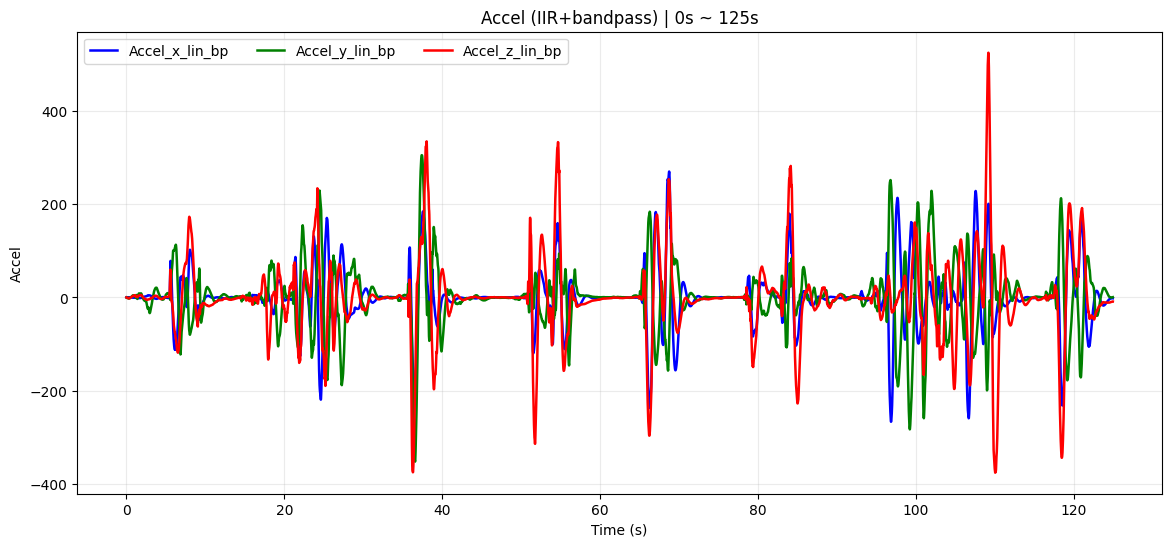

In [3]:


# ============ 新增功能：只取 75s~90s，画“去重力(IIR)+带通”后三轴加速度 ============
t_start, t_end = 0, 125

# 你的 df_acc_lin_bp 来自上一段：对 Accel_*_lin 做带通后得到 Accel_*_lin_bp
mask = (df_acc_lin_bp["time_sec"] >= t_start) & (df_acc_lin_bp["time_sec"] <= t_end)
df_win = df_acc_lin_bp.loc[mask].copy()

print(
    f"window samples: {len(df_win)} | "
    f"time range: {df_win['time_sec'].min():.2f}s ~ {df_win['time_sec'].max():.2f}s"
)

plt.figure(figsize=(14, 6))
plt.plot(df_win["time_sec"], df_win["Accel_x_lin_bp"], label="Accel_x_lin_bp", color="blue",  lw=1.8)
plt.plot(df_win["time_sec"], df_win["Accel_y_lin_bp"], label="Accel_y_lin_bp", color="green", lw=1.8)
plt.plot(df_win["time_sec"], df_win["Accel_z_lin_bp"], label="Accel_z_lin_bp", color="red",   lw=1.8)

plt.xlabel("Time (s)")
plt.ylabel("Accel")
plt.title(f"Accel (IIR+bandpass) | {t_start:.0f}s ~ {t_end:.0f}s")
plt.grid(True, alpha=0.25)
plt.legend(ncol=3)
plt.show()